
# GNN Pipeline

This notebook assumes the dataset is already cleaned and feature engineered.

It runs four experiments:
1. **GNN without feature-engineered columns**
2. **GNN with feature-engineered columns**
3. **GNN with feature-engineered columns + XGBoost stacker**
4. **GNN with feature-engineered columns + CatBoost stacker**


In [1]:
%pip install -q --no-cache-dir numpy==2.0.2 pandas==2.2.2

%pip install -q --no-cache-dir \
  torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 \
  --index-url https://download.pytorch.org/whl/cu121

%pip install -q --no-cache-dir torch-geometric

%pip install -q --no-cache-dir \
  pyg-lib -f https://data.pyg.org/whl/torch-2.3.0+cu121.html

%pip install -q --no-cache-dir xgboost catboost

In [2]:
import numpy as np
import pandas as pd
import torch
import torch_geometric
import xgboost
import catboost

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("pyg:", torch_geometric.__version__)
print("xgboost:", xgboost.__version__)
print("catboost:", catboost.__version__)

numpy: 2.0.2
pandas: 2.2.2
torch: 2.3.1+cu121
cuda available: True
pyg: 2.7.0
xgboost: 3.2.0
catboost: 1.2.10


In [3]:
import random
import copy
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import TransformerConv
from torch_geometric.data import Data
from torch_geometric.loader import LinkNeighborLoader

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
base_path = "/content/drive/MyDrive/dataset_cleaned/HI-Small_Trans.csv"  # change if needed

df = pd.read_csv(base_path)
print("Shape:", df.shape)
df.head()

Shape: (5078336, 21)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,...,Log Amount Received,_ts,tx_hour,tx_dow,tx_month,tx_day,tx_date,tx_is_weekend,tx_hour_sin,tx_hour_cos
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,...,8.215639,2022-09-01 00:20:00,0,3,9,1,2022-09-01,0,0.0,1.0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,...,0.009950,2022-09-01 00:20:00,0,3,9,1,2022-09-01,0,0.0,1.0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,...,9.594008,2022-09-01 00:00:00,0,3,9,1,2022-09-01,0,0.0,1.0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,...,7.940217,2022-09-01 00:02:00,0,3,9,1,2022-09-01,0,0.0,1.0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,...,10.510095,2022-09-01 00:06:00,0,3,9,1,2022-09-01,0,0.0,1.0


In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [7]:
CORE_REQUIRED_COLS = [
    "From Bank", "Account",
    "To Bank", "Account.1",
    "Is Laundering"
]

missing_core = [c for c in CORE_REQUIRED_COLS if c not in df.columns]
if missing_core:
    raise ValueError(f"Missing required core columns: {missing_core}")

print("Core columns check passed.")

Core columns check passed.


In [8]:
def run_epoch_train(model, loader, opt, crit, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch)
        y = batch.edge_label.to(device)

        loss = crit(logits, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        bs = y.numel()
        total_loss += float(loss.item()) * bs

        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(bs)

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)
    return avg_loss, acc


@torch.no_grad()
def run_epoch_eval(model, loader, crit, device, max_batches=None, threshold=0.5):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    probs_all = []
    ys_all = []

    for i, batch in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break

        batch = batch.to(device)

        logits = model(batch)
        y = batch.edge_label.to(device)

        loss = crit(logits, y)

        bs = y.numel()
        total_loss += float(loss.item()) * bs

        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(bs)

        prob1 = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        probs_all.append(prob1)
        ys_all.append(y.detach().cpu().numpy())

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)

    ys = np.concatenate(ys_all) if ys_all else np.array([])
    ps = np.concatenate(probs_all) if probs_all else np.array([])

    if ys.size > 0 and len(np.unique(ys)) > 1:
        pr_auc = average_precision_score(ys, ps)
        roc_auc = roc_auc_score(ys, ps)

        yhat = (ps >= threshold).astype(int)
        cm = confusion_matrix(ys, yhat, labels=[0, 1])
    else:
        pr_auc = np.nan
        roc_auc = np.nan
        yhat = np.array([])
        cm = np.array([[0, 0], [0, 0]])

    pos_rate = float(ys.mean()) if ys.size > 0 else np.nan

    return avg_loss, acc, pos_rate, pr_auc, roc_auc, cm, ys, ps


def plot_confusion_matrix_from_array(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.show()

In [9]:
def build_base_graph(df):
    src_key = df["From Bank"].astype(str) + "|" + df["Account"].astype(str)
    dst_key = df["To Bank"].astype(str) + "|" + df["Account.1"].astype(str)

    all_keys = pd.concat([src_key, dst_key], ignore_index=True)
    codes, uniques = pd.factorize(all_keys, sort=False)

    E = len(src_key)
    src = codes[:E].astype("int64")
    dst = codes[E:].astype("int64")
    num_nodes = len(uniques)

    edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long)
    y_edge = pd.to_numeric(df["Is Laundering"], errors="coerce").fillna(0).astype("int64").to_numpy()
    y_edge_t = torch.tensor(y_edge, dtype=torch.long)

    return edge_index, y_edge_t, num_nodes


def make_fixed_edge_split(num_edges, train_frac=0.70, val_frac=0.10, seed=42):
    g = torch.Generator()
    g.manual_seed(seed)

    edge_ids = torch.arange(num_edges, dtype=torch.long)
    perm = edge_ids[torch.randperm(edge_ids.numel(), generator=g)]

    n_train = int(train_frac * len(perm))
    n_val = int(val_frac * len(perm))

    train_eids = perm[:n_train]
    val_eids = perm[n_train:n_train + n_val]
    test_eids = perm[n_train + n_val:]

    return train_eids, val_eids, test_eids


edge_index, y_edge_t, num_nodes = build_base_graph(df)
train_eids, val_eids, test_eids = make_fixed_edge_split(edge_index.size(1), seed=42)

print("num_nodes:", num_nodes)
print("num_edges:", edge_index.size(1))
print("split sizes -> train:", len(train_eids), "val:", len(val_eids), "test:", len(test_eids))

num_nodes: 515088
num_edges: 5078336
split sizes -> train: 3554835 val: 507833 test: 1015668


## Feature Groups

In [10]:
FEATURE_GROUPS = {
    "raw_amounts": [
        "Amount Received",
        "Amount Paid",
        "Log Amount Received",
    ],
    "currencies": [
        "Receiving Currency",
        "Payment Currency",
    ],
    "payment_format": [
        "Payment Format",
    ],
    "time_basic": [
        "tx_dow",
        "tx_is_weekend",
    ],
    "time_cyclical": [
        "tx_hour_sin",
        "tx_hour_cos",
    ],
    "time_trend": [
        "_ts",
    ]
}

FEATURE_GROUPS = {
    group: [c for c in cols if c in df.columns]
    for group, cols in FEATURE_GROUPS.items()
}
FEATURE_GROUPS = {
    group: cols for group, cols in FEATURE_GROUPS.items()
    if len(cols) > 0
}

print("Usable feature groups:")
for k, v in FEATURE_GROUPS.items():
    print(f"{k}: {v}")

Usable feature groups:
raw_amounts: ['Amount Received', 'Amount Paid', 'Log Amount Received']
currencies: ['Receiving Currency', 'Payment Currency']
payment_format: ['Payment Format']
time_basic: ['tx_dow', 'tx_is_weekend']
time_cyclical: ['tx_hour_sin', 'tx_hour_cos']
time_trend: ['_ts']


In [11]:
CATEGORICAL_COLS = {
    "Receiving Currency",
    "Payment Currency",
    "Payment Format",
}

SPECIAL_DOW_COL = "tx_dow"
SPECIAL_TS_COLS = {"_ts", "Timestamp_norm"}

In [12]:
def encode_numeric_column(series):
    vals = pd.to_numeric(series, errors="coerce").fillna(0).astype(np.float32).to_numpy()
    if vals.size > 0:
        vmax = np.nanmax(np.abs(vals))
        if np.isfinite(vmax) and vmax > 0:
            vals = vals / vmax
    return vals.reshape(-1, 1), [series.name]


def encode_categorical_column(series):
    vals = series.astype(str).fillna("MISSING")
    uniq = pd.Index(vals.unique())
    if len(uniq) == 0:
        return np.zeros((len(series), 1), dtype=np.float32), [f"{series.name}__EMPTY"]

    codes = pd.Categorical(vals, categories=uniq).codes
    onehot = np.eye(len(uniq), dtype=np.float32)[codes]
    col_names = [f"{series.name}__{u}" for u in uniq]
    return onehot.astype(np.float32), col_names


def encode_dow_column(series):
    dow = pd.to_numeric(series, errors="coerce").fillna(0).astype(np.int64).to_numpy()
    dow = np.clip(dow, 0, 6)
    onehot = np.eye(7, dtype=np.float32)[dow]
    col_names = [f"tx_dow_{i}" for i in range(7)]
    return onehot.astype(np.float32), col_names


def encode_ts_column(series):
    ts = pd.to_datetime(series, errors="coerce")
    if ts.notna().sum() == 0:
        vals = np.zeros(len(series), dtype=np.float32)
    else:
        ts = ts.fillna(ts.dropna().min())
        t0 = ts.min()
        vals = (ts - t0).dt.total_seconds().astype(np.float32).to_numpy()
        vmax = float(np.max(vals)) if len(vals) > 0 else 0.0
        if vmax > 0:
            vals = vals / vmax
    return vals.reshape(-1, 1).astype(np.float32), [f"{series.name}_norm"]


def build_edge_attr_from_feature_cols(df, feature_cols):
    parts = []
    feature_names = []

    for col in feature_cols:
        if col not in df.columns:
            continue

        s = df[col]

        if col in SPECIAL_TS_COLS:
            arr, names = encode_ts_column(s)
        elif col == SPECIAL_DOW_COL:
            arr, names = encode_dow_column(s)
        elif col in CATEGORICAL_COLS:
            arr, names = encode_categorical_column(s)
        else:
            arr, names = encode_numeric_column(s)

        parts.append(arr)
        feature_names.extend(names)

    if len(parts) == 0:
        edge_attr = np.zeros((len(df), 1), dtype=np.float32)
        feature_names = ["dummy_feature"]

    else:
        edge_attr = np.concatenate(parts, axis=1).astype(np.float32)

    return edge_attr, feature_names

In [13]:
def make_loaders_for_feature_cols(
    df,
    edge_index,
    y_edge_t,
    num_nodes,
    train_eids,
    val_eids,
    test_eids,
    feature_cols,
    num_neighbors=[15, 10],
    batch_size=4096,
):
    edge_attr_np, expanded_feature_names = build_edge_attr_from_feature_cols(df, feature_cols)
    edge_attr_t = torch.tensor(edge_attr_np, dtype=torch.float32)

    data = Data(num_nodes=num_nodes, edge_index=edge_index, edge_attr=edge_attr_t)

    train_loader = LinkNeighborLoader(
        data,
        edge_label_index=edge_index[:, train_eids],
        edge_label=y_edge_t[train_eids],
        num_neighbors=num_neighbors,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = LinkNeighborLoader(
        data,
        edge_label_index=edge_index[:, val_eids],
        edge_label=y_edge_t[val_eids],
        num_neighbors=num_neighbors,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = LinkNeighborLoader(
        data,
        edge_label_index=edge_index[:, test_eids],
        edge_label=y_edge_t[test_eids],
        num_neighbors=num_neighbors,
        batch_size=batch_size,
        shuffle=False
    )

    return data, train_loader, val_loader, test_loader, expanded_feature_names

In [14]:
class EdgeAwareGNN(nn.Module):
    def __init__(self, num_nodes, hidden=128, edge_dim=1):
        super().__init__()
        self.emb = nn.Embedding(num_nodes, hidden)
        self.conv1 = TransformerConv(hidden, hidden, edge_dim=edge_dim)
        self.conv2 = TransformerConv(hidden, hidden, edge_dim=edge_dim)
        self.mlp = nn.Sequential(
            nn.Linear(hidden * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, batch):
        x = self.emb(batch.n_id)
        x = F.relu(self.conv1(x, batch.edge_index, batch.edge_attr))
        x = self.conv2(x, batch.edge_index, batch.edge_attr)

        src_i = batch.edge_label_index[0]
        dst_i = batch.edge_label_index[1]
        hs = x[src_i]
        hd = x[dst_i]
        h = torch.cat([hs, hd, hs * hd, (hs - hd).abs()], dim=-1)
        return self.mlp(h)

In [15]:
def train_and_score_feature_set(
    set_name,
    feature_cols,
    df,
    edge_index,
    y_edge_t,
    num_nodes,
    train_eids,
    val_eids,
    test_eids,
    device,
    hidden=128,
    lr=2e-3,
    epochs=3,
    batch_size=4096,
    num_neighbors=[15, 10],
    eval_test=False,
    max_eval_batches=200,
    threshold=0.5,
):
    data, train_loader, val_loader, test_loader, expanded_feature_names = make_loaders_for_feature_cols(
        df=df,
        edge_index=edge_index,
        y_edge_t=y_edge_t,
        num_nodes=num_nodes,
        train_eids=train_eids,
        val_eids=val_eids,
        test_eids=test_eids,
        feature_cols=feature_cols,
        num_neighbors=num_neighbors,
        batch_size=batch_size,
    )

    edge_dim = data.edge_attr.size(1)

    model = EdgeAwareGNN(
        num_nodes=num_nodes,
        hidden=hidden,
        edge_dim=edge_dim
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    history = []
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch_train(model, train_loader, opt, crit, device)

        va_loss, va_acc, _, va_pr, va_roc, va_cm, _, _ = run_epoch_eval(
            model,
            val_loader,
            crit,
            device,
            max_batches=max_eval_batches,
            threshold=threshold,
        )

        history.append({
            "epoch": epoch,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "val_loss": va_loss,
            "val_acc": va_acc,
            "val_pr_auc": va_pr,
            "val_roc_auc": va_roc,
            "val_confusion_matrix": va_cm,
        })

        print(
            f"[{set_name}] epoch {epoch} | "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
            f"val PR {va_pr:.4f} | val ROC {va_roc:.4f}"
        )

    _, _, val_pos_rate, val_pr_auc, val_roc_auc, val_cm, val_y, val_p = run_epoch_eval(
        model,
        val_loader,
        crit,
        device,
        max_batches=max_eval_batches,
        threshold=threshold,
    )

    result = {
        "feature_set": set_name,
        "feature_cols": feature_cols,
        "expanded_feature_names": expanded_feature_names,
        "num_raw_features": len(feature_cols),
        "num_features_after_encoding": edge_dim,
        "val_pos_rate": val_pos_rate,
        "val_pr_auc": val_pr_auc,
        "val_roc_auc": val_roc_auc,
        "val_confusion_matrix": val_cm,
        "val_y_true": val_y,
        "val_y_prob": val_p,
        "history": history,
        "model_state_dict": copy.deepcopy(model.state_dict()),
    }

    if eval_test:
        _, _, test_pos_rate, test_pr_auc, test_roc_auc, test_cm, test_y, test_p = run_epoch_eval(
            model,
            test_loader,
            crit,
            device,
            max_batches=max_eval_batches,
            threshold=threshold,
        )
        result["test_pos_rate"] = test_pos_rate
        result["test_pr_auc"] = test_pr_auc
        result["test_roc_auc"] = test_roc_auc
        result["test_confusion_matrix"] = test_cm
        result["test_y_true"] = test_y
        result["test_y_prob"] = test_p

    return result

In [16]:
RAW_BASE = ["raw_amounts", "currencies", "payment_format"]

FEATURE_SET_LIBRARY = {
    "raw_only": RAW_BASE,
    "time_only_current_engineered": ["raw_amounts", "time_basic", "time_cyclical", "time_trend"],
    "raw_plus_time_basic": RAW_BASE + ["time_basic"],
    "raw_plus_time_cyclical": RAW_BASE + ["time_cyclical"],
    "raw_plus_all_time": RAW_BASE + ["time_basic", "time_cyclical", "time_trend"],
}

FEATURE_SET_LIBRARY = {
    name: [g for g in groups if g in FEATURE_GROUPS]
    for name, groups in FEATURE_SET_LIBRARY.items()
}
FEATURE_SET_LIBRARY = {
    name: groups for name, groups in FEATURE_SET_LIBRARY.items()
    if len(groups) > 0
}

for k, v in FEATURE_SET_LIBRARY.items():
    print(f"{k}: {v}")

raw_only: ['raw_amounts', 'currencies', 'payment_format']
time_only_current_engineered: ['raw_amounts', 'time_basic', 'time_cyclical', 'time_trend']
raw_plus_time_basic: ['raw_amounts', 'currencies', 'payment_format', 'time_basic']
raw_plus_time_cyclical: ['raw_amounts', 'currencies', 'payment_format', 'time_cyclical']
raw_plus_all_time: ['raw_amounts', 'currencies', 'payment_format', 'time_basic', 'time_cyclical', 'time_trend']


In [17]:
def flatten_feature_groups(group_list, feature_groups):
    cols = []
    for g in group_list:
        cols.extend(feature_groups[g])
    # preserve order while removing duplicates
    return list(dict.fromkeys(cols))


def generate_feature_set_library_from_groups(
    feature_groups,
    min_groups=1,
    max_groups=3,
    required_groups=None,
):
    group_names = list(feature_groups.keys())
    required_groups = required_groups or []

    library = {}
    for r in range(min_groups, max_groups + 1):
        for combo in combinations(group_names, r):
            combo = list(combo)

            if required_groups and not set(required_groups).issubset(set(combo)):
                continue

            set_name = " + ".join(combo)
            library[set_name] = combo

    return library

In [18]:
SEARCH_LIBRARY = generate_feature_set_library_from_groups(
    feature_groups=FEATURE_GROUPS,
    min_groups=3,
    max_groups=5,
    required_groups=RAW_BASE
)

print("Total feature sets to evaluate:", len(SEARCH_LIBRARY))
for k, v in SEARCH_LIBRARY.items():
    print(f"{k}: {v}")

Total feature sets to evaluate: 7
raw_amounts + currencies + payment_format: ['raw_amounts', 'currencies', 'payment_format']
raw_amounts + currencies + payment_format + time_basic: ['raw_amounts', 'currencies', 'payment_format', 'time_basic']
raw_amounts + currencies + payment_format + time_cyclical: ['raw_amounts', 'currencies', 'payment_format', 'time_cyclical']
raw_amounts + currencies + payment_format + time_trend: ['raw_amounts', 'currencies', 'payment_format', 'time_trend']
raw_amounts + currencies + payment_format + time_basic + time_cyclical: ['raw_amounts', 'currencies', 'payment_format', 'time_basic', 'time_cyclical']
raw_amounts + currencies + payment_format + time_basic + time_trend: ['raw_amounts', 'currencies', 'payment_format', 'time_basic', 'time_trend']
raw_amounts + currencies + payment_format + time_cyclical + time_trend: ['raw_amounts', 'currencies', 'payment_format', 'time_cyclical', 'time_trend']


In [19]:
EPOCHS = 3
HIDDEN = 128
LR = 2e-3
BATCH_SIZE = 4096
NUM_NEIGHBORS = [15, 10]
MAX_EVAL_BATCHES = 200

EVAL_TEST_DURING_SEARCH = False

all_results = []

for set_name, group_list in SEARCH_LIBRARY.items():
    feature_cols = flatten_feature_groups(group_list, FEATURE_GROUPS)
    feature_cols = [c for c in feature_cols if c in df.columns]

    if len(feature_cols) == 0:
        print(f"Skipping {set_name} because no usable columns were found.")
        continue

    print("\n" + "=" * 90)
    print("Running feature set:", set_name)
    print("Groups:", group_list)
    print("Columns:", feature_cols)

    try:
        result = train_and_score_feature_set(
            set_name=set_name,
            feature_cols=feature_cols,
            df=df,
            edge_index=edge_index,
            y_edge_t=y_edge_t,
            num_nodes=num_nodes,
            train_eids=train_eids,
            val_eids=val_eids,
            test_eids=test_eids,
            device=device,
            hidden=HIDDEN,
            lr=LR,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            num_neighbors=NUM_NEIGHBORS,
            eval_test=EVAL_TEST_DURING_SEARCH,
            max_eval_batches=MAX_EVAL_BATCHES,
        )
        all_results.append(result)

    except Exception as e:
        print(f"Failed on {set_name}: {e}")
        all_results.append({
            "feature_set": set_name,
            "feature_cols": feature_cols,
            "expanded_feature_names": None,
            "num_raw_features": len(feature_cols),
            "num_features_after_encoding": None,
            "val_pos_rate": np.nan,
            "val_pr_auc": np.nan,
            "val_roc_auc": np.nan,
            "error": str(e)
        })


Running feature set: raw_amounts + currencies + payment_format
Groups: ['raw_amounts', 'currencies', 'payment_format']
Columns: ['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency', 'Payment Currency', 'Payment Format']
[raw_amounts + currencies + payment_format] epoch 1 | train loss 0.0078 acc 0.9987 | val loss 0.0049 acc 0.9992 | val PR 0.3975 | val ROC 0.9131
[raw_amounts + currencies + payment_format] epoch 2 | train loss 0.0038 acc 0.9993 | val loss 0.0047 acc 0.9992 | val PR 0.4255 | val ROC 0.9212
[raw_amounts + currencies + payment_format] epoch 3 | train loss 0.0027 acc 0.9994 | val loss 0.0059 acc 0.9992 | val PR 0.4075 | val ROC 0.8968

Running feature set: raw_amounts + currencies + payment_format + time_basic
Groups: ['raw_amounts', 'currencies', 'payment_format', 'time_basic']
Columns: ['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency', 'Payment Currency', 'Payment Format', 'tx_dow', 'tx_is_weekend']
[raw_amounts + cu

In [20]:
results_rows = []
for r in all_results:
    row = {
        "feature_set": r.get("feature_set"),
        "num_raw_features": r.get("num_raw_features"),
        "num_features_after_encoding": r.get("num_features_after_encoding"),
        "val_pr_auc": r.get("val_pr_auc"),
        "val_roc_auc": r.get("val_roc_auc"),
        "error": r.get("error", None),
    }

    if "test_pr_auc" in r:
        row["test_pr_auc"] = r.get("test_pr_auc")
        row["test_roc_auc"] = r.get("test_roc_auc")

    results_rows.append(row)

results_df = pd.DataFrame(results_rows).sort_values(
    by="val_pr_auc",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

display(results_df)

,feature_set,num_raw_features,num_features_after_encoding,val_pr_auc,val_roc_auc,error
0,raw_amounts + currencies + payment_format,6,40,0.408218,0.900860,None
1,raw_amounts + currencies + payment_format + ti...,9,49,0.401181,0.911345,None
2,raw_amounts + currencies + payment_format + ti...,7,41,0.394441,0.911123,None
3,raw_amounts + currencies + payment_format + ti...,9,43,0.392520,0.906008,None
4,raw_amounts + currencies + payment_format + ti...,8,48,0.390116,0.908137,None
5,raw_amounts + currencies + payment_format + ti...,10,50,0.383082,0.898502,None
6,raw_amounts + currencies + payment_format + ti...,8,42,0.376676,0.894192,None


Feature set: raw_amounts + currencies + payment_format
Val PR-AUC: 0.4082
Val ROC-AUC: 0.9009
Validation confusion matrix:
[[507247     54]
 [   336    196]]


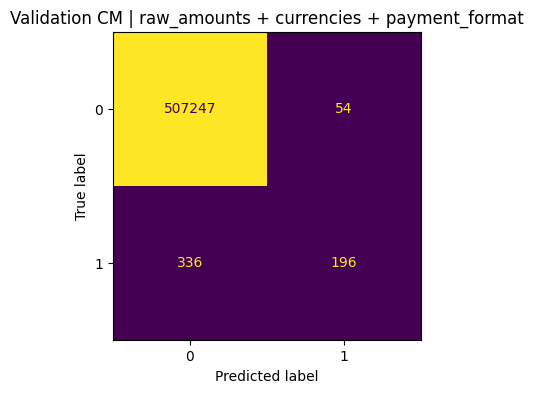

Feature set: raw_amounts + currencies + payment_format + time_basic
Val PR-AUC: 0.3901
Val ROC-AUC: 0.9081
Validation confusion matrix:
[[507248     53]
 [   339    193]]


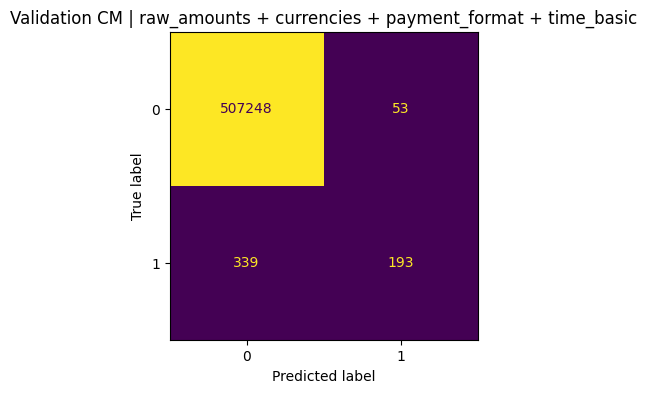

Feature set: raw_amounts + currencies + payment_format + time_cyclical
Val PR-AUC: 0.3767
Val ROC-AUC: 0.8942
Validation confusion matrix:
[[507221     80]
 [   332    200]]


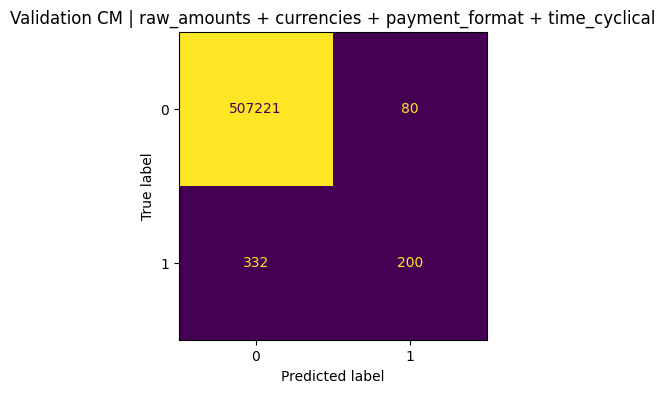

Feature set: raw_amounts + currencies + payment_format + time_trend
Val PR-AUC: 0.3944
Val ROC-AUC: 0.9111
Validation confusion matrix:
[[507232     69]
 [   341    191]]


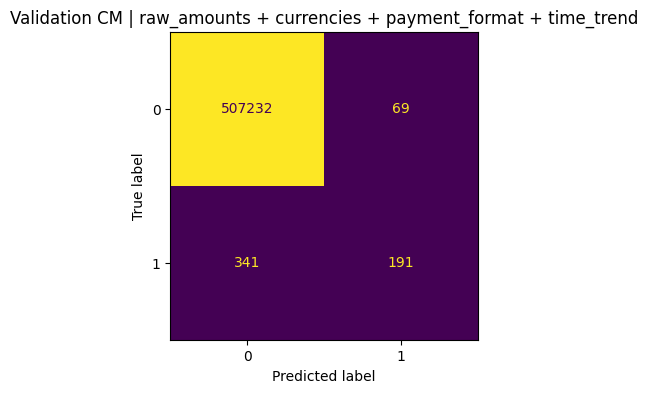

Feature set: raw_amounts + currencies + payment_format + time_basic + time_cyclical
Val PR-AUC: 0.3831
Val ROC-AUC: 0.8985
Validation confusion matrix:
[[507172    129]
 [   312    220]]


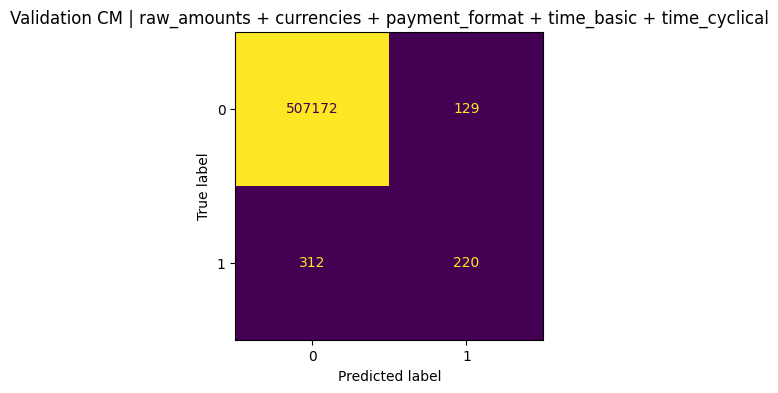

Feature set: raw_amounts + currencies + payment_format + time_basic + time_trend
Val PR-AUC: 0.4012
Val ROC-AUC: 0.9113
Validation confusion matrix:
[[507253     48]
 [   368    164]]


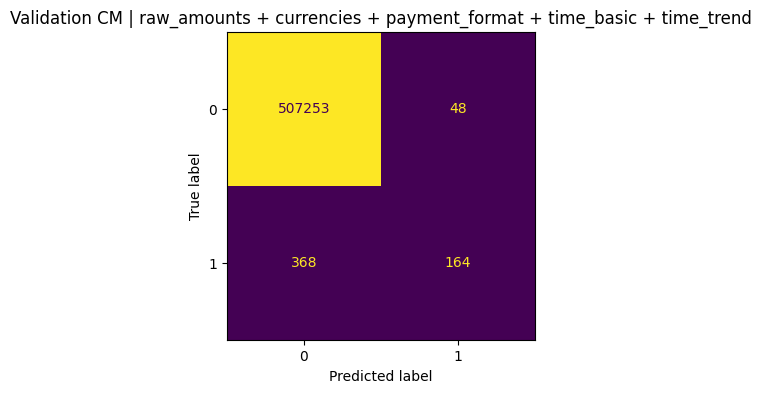

Feature set: raw_amounts + currencies + payment_format + time_cyclical + time_trend
Val PR-AUC: 0.3925
Val ROC-AUC: 0.9060
Validation confusion matrix:
[[507217     84]
 [   330    202]]


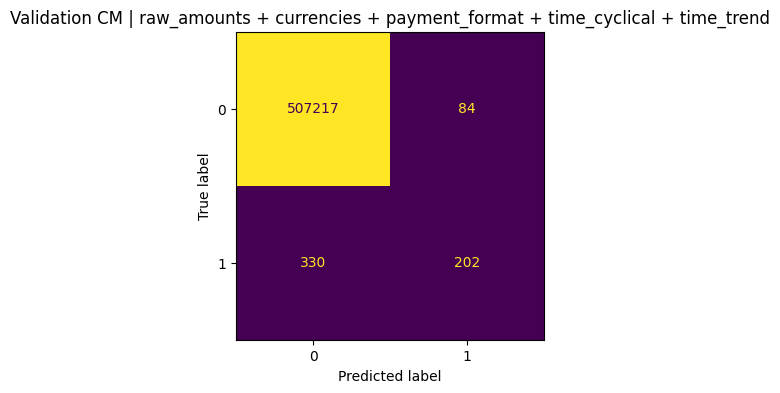

In [21]:
for r in all_results:
    if "val_confusion_matrix" not in r:
        continue

    print("=" * 80)
    print("Feature set:", r["feature_set"])
    print(f"Val PR-AUC: {r.get('val_pr_auc', np.nan):.4f}")
    print(f"Val ROC-AUC: {r.get('val_roc_auc', np.nan):.4f}")
    print("Validation confusion matrix:")
    print(r["val_confusion_matrix"])

    plot_confusion_matrix_from_array(
        r["val_confusion_matrix"],
        title=f"Validation CM | {r['feature_set']}"
    )

In [22]:
valid_results = [r for r in all_results if not pd.isna(r.get("val_pr_auc", np.nan))]
if len(valid_results) == 0:
    raise ValueError("No successful runs were completed.")

best_result = max(valid_results, key=lambda x: x["val_pr_auc"])

print("Best feature set by validation PR-AUC:")
print(best_result["feature_set"])
print()
print("Raw columns:")
print(best_result["feature_cols"])
print()
print("Expanded encoded columns:")
print(best_result["expanded_feature_names"])
print()
print("Validation PR-AUC:", best_result["val_pr_auc"])
print("Validation ROC-AUC:", best_result["val_roc_auc"])

Best feature set by validation PR-AUC:
raw_amounts + currencies + payment_format

Raw columns:
['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency', 'Payment Currency', 'Payment Format']

Expanded encoded columns:
['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency__US Dollar', 'Receiving Currency__Bitcoin', 'Receiving Currency__Euro', 'Receiving Currency__Australian Dollar', 'Receiving Currency__Yuan', 'Receiving Currency__Rupee', 'Receiving Currency__Mexican Peso', 'Receiving Currency__Yen', 'Receiving Currency__UK Pound', 'Receiving Currency__Ruble', 'Receiving Currency__Canadian Dollar', 'Receiving Currency__Swiss Franc', 'Receiving Currency__Brazil Real', 'Receiving Currency__Saudi Riyal', 'Receiving Currency__Shekel', 'Payment Currency__US Dollar', 'Payment Currency__Bitcoin', 'Payment Currency__Euro', 'Payment Currency__Australian Dollar', 'Payment Currency__Yuan', 'Payment Currency__Rupee', 'Payment Currency__Yen', 'Payment Cu